# AlexNet Implementation with CIFAR-10 in Keras

***1. IMPORTS***

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout,BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

***2. Load Data***

In [ ]:
# Load and preprocess CIFAR-10
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1518s 9us/step


***3. Normalize***

In [ ]:
x_train = x_train.astype('float32') /255.0
x_test = x_test.astype('float32') /255.0

***4. One Hot Encoding***

In [ ]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

***5. Define AlexNet model (adapted for CIFAR-10)***

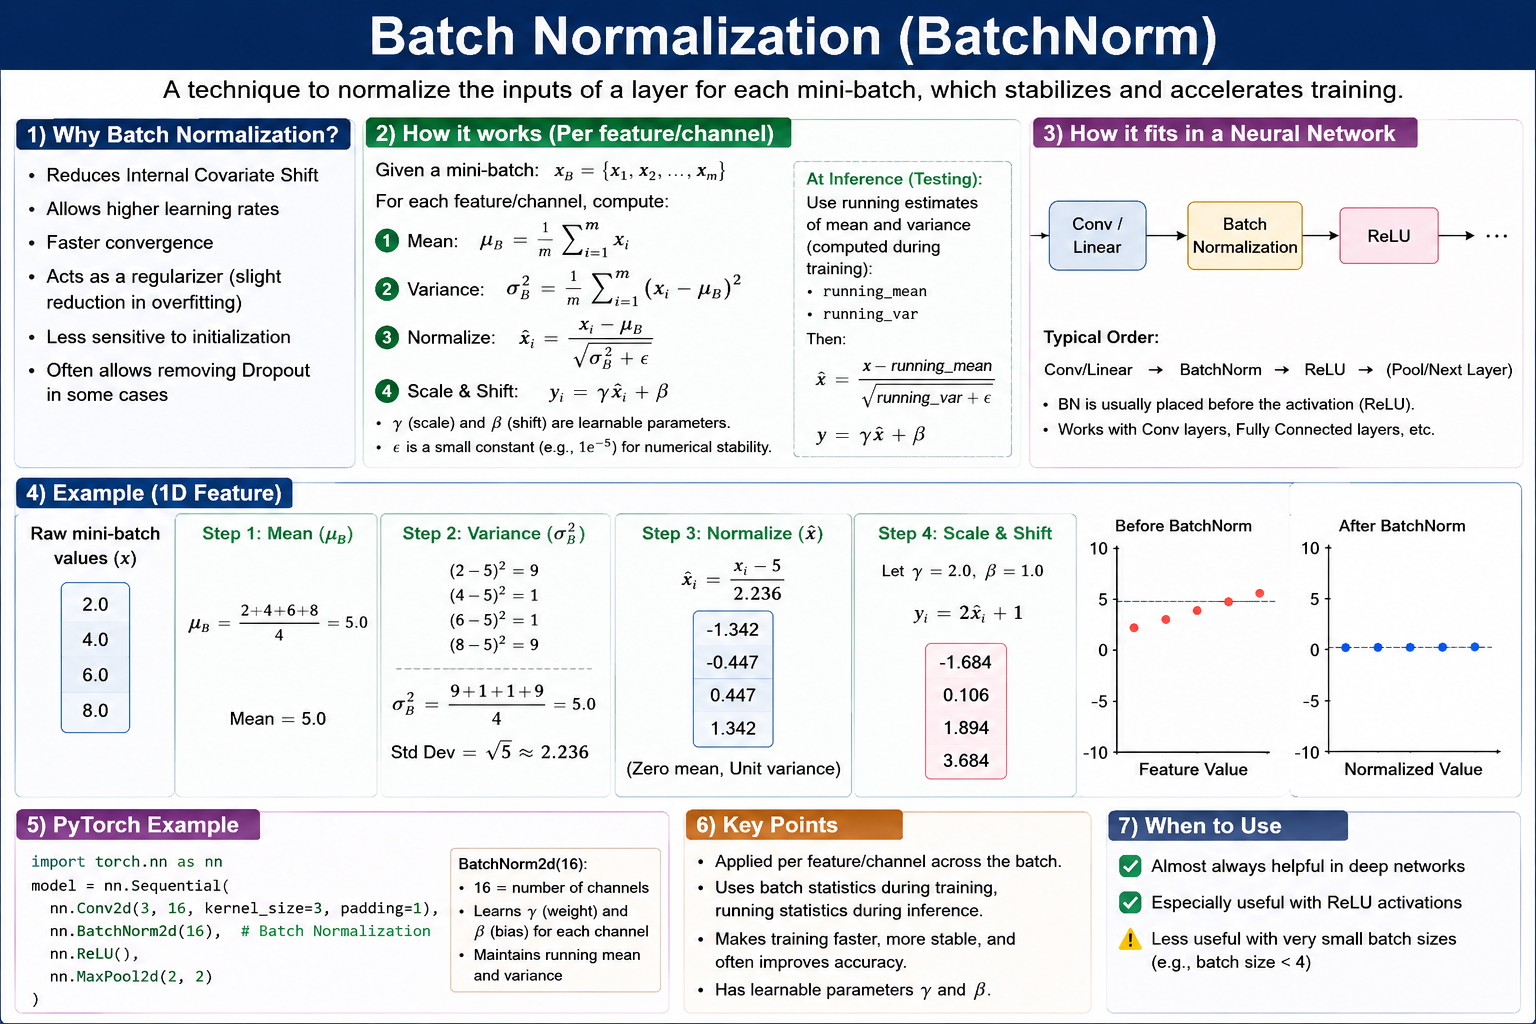

***Batch Normalization normalizes the values coming from a layer so that the next layer receives more stable inputs.***

In [ ]:
model = Sequential()

# 1st convolution layer
model.add(Conv2D(96,(3,3),activation='relu',input_shape=(32, 32, 3),padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd convolution Layer
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# 3rd convolution layer
model.add(Conv2D(384,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())

# 4th convolution layer
model.add(Conv2D(384,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())

# 5th convolution layer
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten and Dense Layer
model.add(Flatten())
model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


***6. Model Summary***

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,930,826 (140.88 MB)

 Trainable params: 36,928,074 (140.87 MB)

 Non-trainable params: 2,752 (10.75 KB)

***7. Model Compilation***

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

***8. Model Training***

In [ ]:
hist = model.fit(x_train,y_train,
                 batch_size=128,
                 epochs=20,
                 validation_split=0.2,
                 verbose=1)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.3844 - loss: 2.0155 - val_accuracy: 0.1511 - val_loss: 3.2096
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.5482 - loss: 1.2875 - val_accuracy: 0.5030 - val_loss: 1.3859
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6327 - loss: 1.0685 - val_accuracy: 0.4338 - val_loss: 1.5625
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6884 - loss: 0.9153 - val_accuracy: 0.6779 - val_loss: 0.9381
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.7337 - loss: 0.7906 - val_accuracy: 0.7019 - val_loss: 0.8880
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7692 - loss: 0.6944 - val_accuracy: 0.6640 - val_loss: 0.9707
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8059 - loss: 0.5983 - val_accuracy: 0.6724 - val_loss: 0.9967
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8330 - loss: 0.5118 - 

***9. Model Evaluation***

In [ ]:
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=1)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7591 - loss: 1.0236
Test accuracy: 0.7591


In [ ]:
hist.history.items()

dict_items([('accuracy', [0.3844499886035919, 0.5481500029563904, 0.6326500177383423, 0.6883749961853027, 0.7337499856948853, 0.7691749930381775, 0.8058500289916992, 0.8329749703407288, 0.8574749827384949, 0.8784499764442444, 0.8960750102996826, 0.916225016117096, 0.9280250072479248, 0.9328250288963318, 0.9458249807357788, 0.9491000175476074, 0.9574499726295471, 0.9616249799728394, 0.9624249935150146, 0.9433500170707703]), ('loss', [2.0155441761016846, 1.2874687910079956, 1.0684893131256104, 0.9152920842170715, 0.7906357645988464, 0.6943500638008118, 0.598296046257019, 0.5118024945259094, 0.43191200494766235, 0.383186936378479, 0.3233601748943329, 0.26703038811683655, 0.23059453070163727, 0.21490585803985596, 0.1856999397277832, 0.17116296291351318, 0.14018964767456055, 0.1304931342601776, 0.13367721438407898, 0.21060065925121307]), ('val_accuracy', [0.15109999477863312, 0.503000020980835, 0.43380001187324524, 0.6779000163078308, 0.7019000053405762, 0.6639999747276306, 0.67239999771118

***10. Plot training history***

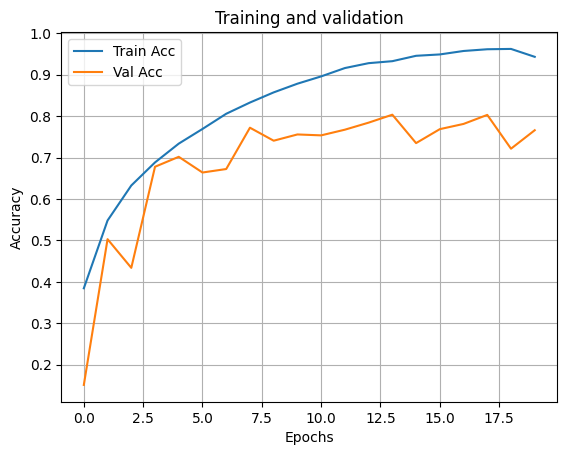

In [ ]:
# Plot training history
plt.plot(hist.history['accuracy'],label='Train Acc')
plt.plot(hist.history['val_accuracy'],label='Val Acc')
plt.title('Training and validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

***11. Inference (Predict sample images)***

In [ ]:
# Inference (Predict sample images)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

***12. Visualization***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


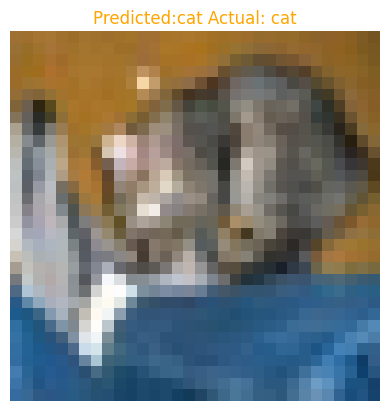

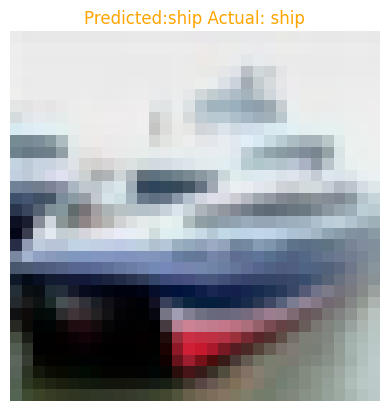

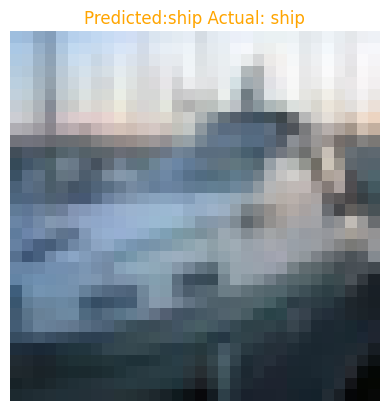

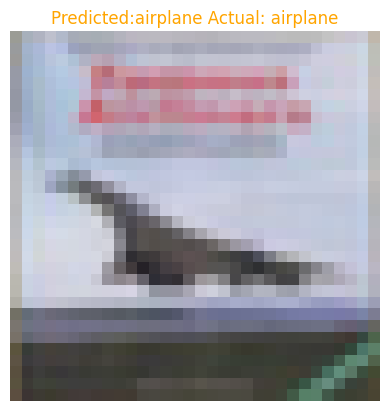

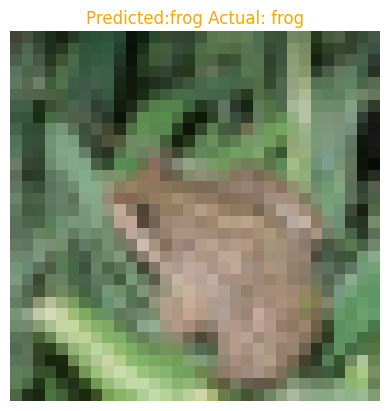

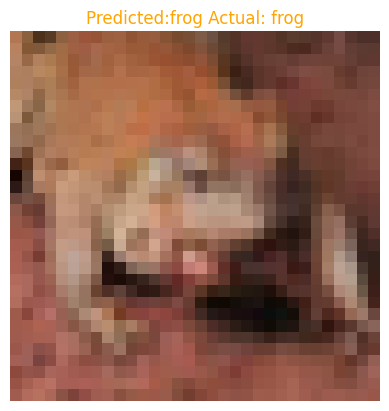

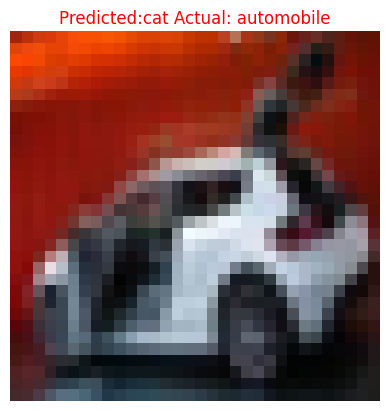

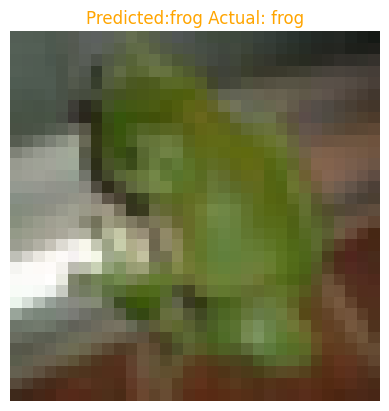

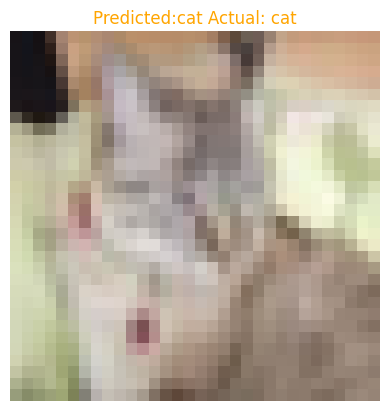

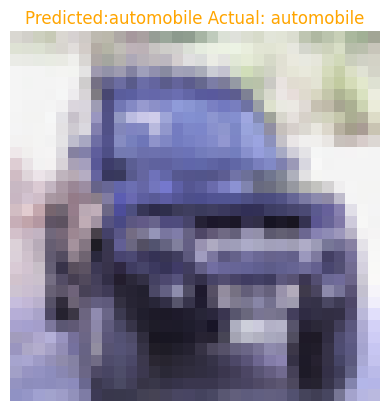

In [ ]:
preds=model.predict(x_test[:10])
for i, pred in enumerate(preds):
  plt.imshow(x_test[i])
  pred_lbl = class_names[np.argmax(pred)]
  actual_lbl = class_names[np.argmax(y_test[i])]
  plt.title(f"Predicted:{pred_lbl} Actual: {actual_lbl}",color = 'orange' if actual_lbl==pred_lbl else 'red')
  plt.axis('off')
  plt.show()

In [ ]:
pred = model.predict(np.expand_dims(x_test[0], axis=0))
print(np.argmax(pred))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
3


array([[0.00408924, 0.00154386, 0.01523961, 0.848138  , 0.02777204,
        0.0349548 , 0.05754727, 0.00417392, 0.00532653, 0.00121462]],
      dtype=float32)

In [ ]:
print(y_test[0])
print(np.argmax(y_test[0]))
class_names[np.argmax(y_test[0])]

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
3


'cat'

# AlexNet Implementation with CIFAR-10 in pytorch

***1. Imports***

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

***2. Preprocessing***

In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),
                             (0.5,0.5,0.5))
    ]
)

***3. DataLoader***

In [ ]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
    )
trainloader = DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
    )


testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
    )
testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False
    )

***4. Model Architechure***

- inplace tells PyTorch whether to modify the input tensor directly or create a new tensor.

In [ ]:
class AlexNet(nn.Module):
  def __init__(self):
    super(AlexNet,self).__init__()
    # covolution layer
    self.features = nn.Sequential(
        nn.Conv2d(3,64,kernel_size=(11,11),stride=4,padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3,stride=2),

        nn.Conv2d(64,192,kernel_size=5,padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3,stride=2),

        nn.Conv2d(192,384,kernel_size=3,padding=1),
        nn.ReLU(inplace=True),

        nn.Conv2d(384,256,kernel_size=3,padding=1),
        nn.ReLU(inplace=True),

        nn.Conv2d(256,256,kernel_size=3,padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3,stride=2)
    )


    # Fully connected and output Layer
    self.classifier = nn.Sequential(
        nn.Dropout(),
        nn.Linear(256*6*6,4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096,4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096,10)
    )


  # Forward propogation
  def forward(self,x):
    x = self.features(x)
    x = x.view(x.size(0),256*6*6)
    x = self.classifier(x)
    return x



***5. Parameters***

In [ ]:
print(model.parameters())

<generator object Module.parameters at 0x78febde03e60>


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0001)

***6. Training***

In [ ]:
trainloader

In [ ]:
for epoch in range(10):
  model.train()
  running_loss = 0
  correct = 0
  total = 0

  for img,lbl in trainloader:
    img,lbl = img.to(device),lbl.to(device)
    optimizer.zero_grad()
    outputs = model(img)
    loss = criterion(outputs,lbl)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    _ , predicted = torch.max(outputs.data,1)
    total += lbl.size(0)
    correct += (predicted == lbl).sum().item()
  print("Epoch {}/{} Loss {:.4f} Accuracy {:.2f}".format(
      epoch+1,
      10,
      running_loss/len(trainloader),
      100*correct/total))

Epoch 1/10 Loss 1.6175 Accuracy 40.21
Epoch 2/10 Loss 1.1849 Accuracy 57.46
Epoch 3/10 Loss 0.9610 Accuracy 65.67
Epoch 4/10 Loss 0.8149 Accuracy 71.27
Epoch 5/10 Loss 0.6956 Accuracy 75.43
Epoch 6/10 Loss 0.6046 Accuracy 78.89
Epoch 7/10 Loss 0.5340 Accuracy 81.31
Epoch 8/10 Loss 0.4725 Accuracy 83.45
Epoch 9/10 Loss 0.4026 Accuracy 85.95
Epoch 10/10 Loss 0.3482 Accuracy 87.90


***7. Evaluation***

In [50]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for imgs,lbls in testloader:
    imgs,lbls = imgs.to(device), lbls.to(device)
    output = model(imgs)
    _, predicted = torch.max(output.data,1)
    total += lbls.size(0)
    correct += (predicted == lbls).sum().item()
print("Test Accuracy {:.2f}%".format(100*correct/total))

Test Accuracy 81.53%


***8. Visualization***

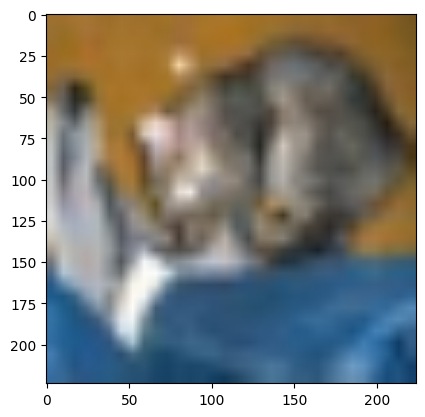

Predicted: cat
Actual: cat


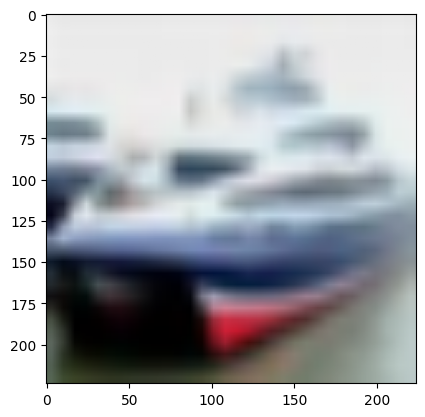

Predicted: ship
Actual: ship


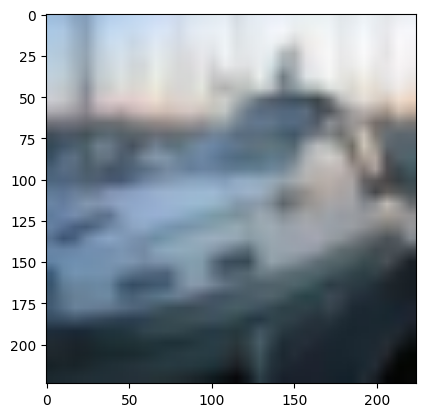

Predicted: ship
Actual: ship


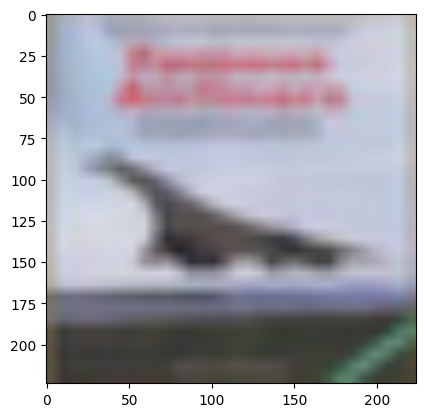

Predicted: plane
Actual: plane


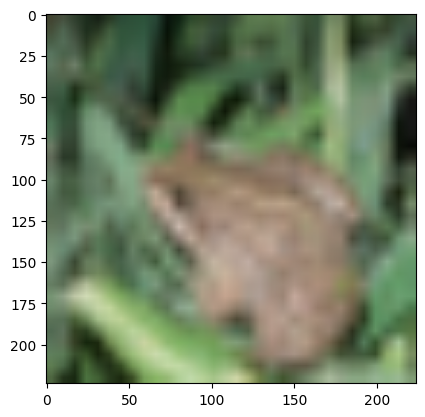

Predicted: frog
Actual: frog


In [52]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
dataiter = iter(testloader)
img,lbl = next(dataiter)
img,lbl = img.to(device), lbl.to(device)

model.eval()

with torch.no_grad():
  output = model(img)
  _, predicted = torch.max(output,1)

def show(img):
  img = img/2 + 0.5
  npimg = img.cpu().numpy()  # Moved tensor to CPU before converting to NumPy
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.show()

for i in range(5):
    show(img[i])
    print("Predicted:", classes[predicted[i].item()]) # Added .item() to get scalar value
    print("Actual:", classes[lbl[i].item()]) # Added .item() to get scalar value